In [3]:
# Importer les bibliothèques necessaires
!pip install gdown
import gdown
import pandas as pd
import re
import gc
import os
import sys
import pandas as pd
import numpy as np
import tqdm
import seaborn as sns

import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from scipy.stats import chi2_contingency
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score, recall_score, roc_curve, auc, classification_report, confusion_matrix, roc_auc_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [gdown]


In [4]:
np.random.seed(123)

In [37]:
# Charger les données
df = pd.read_csv('Fraud Detection Dataset.csv')  # changer le nom du fichier si nécessaire
print('Forme du dataset chargé :', df.shape)
print(df['Fraudulent'].value_counts())


Forme du dataset chargé : (51000, 12)
Fraudulent
0    48490
1     2510
Name: count, dtype: int64


1ère méthode de remplissage des Na : moyenne

Retourne le dataset "df_mean"

In [38]:
# Séparation des colonnes numériques et catégorielles
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('Fraudulent')
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

# Création d'une copie de sécurité
df_mean = df.copy()

# Remplacement des valeurs manquantes pour les variables numériques
for col in numeric_cols:
    for fraud_value in [0, 1]:
        mean_value = df_mean.loc[df_mean['Fraudulent'] == fraud_value, col].mean()
        df_mean.loc[
            (df_mean['Fraudulent'] == fraud_value) & (df_mean[col].isna()),
            col
        ] = mean_value

# Remplacement des valeurs manquantes pour les variables catégorielles
for col in categorical_cols:
    for fraud_value in [0, 1]:
        mode_series = df_mean.loc[df_mean['Fraudulent'] == fraud_value, col].mode()
        if not mode_series.empty:
            mode_value = mode_series.iloc[0]
            df_mean.loc[
                (df_mean['Fraudulent'] == fraud_value) & (df_mean[col].isna()),
                col
            ] = mode_value

# Vérification du remplissage
print("Pourcentage de valeurs manquantes après traitement :")
print((df_mean.isnull().mean() * 100).round(3))

Pourcentage de valeurs manquantes après traitement :
Transaction_ID                      0.0
User_ID                             0.0
Transaction_Amount                  0.0
Transaction_Type                    0.0
Time_of_Transaction                 0.0
Device_Used                         0.0
Location                            0.0
Previous_Fraudulent_Transactions    0.0
Account_Age                         0.0
Number_of_Transactions_Last_24H     0.0
Payment_Method                      0.0
Fraudulent                          0.0
dtype: float64


/tmp/ipykernel_6897/1910456956.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3002.9993194473086' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_mean.loc[
/tmp/ipykernel_6897/1910456956.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.9953598680140234' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_mean.loc[
/tmp/ipykernel_6897/1910456956.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '59.98537842854197' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_mean.loc[
/tmp/ipykernel_6897/1910456956.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a 

2ème méthode de remplissage des Na : interpolation Bayesienne

Retourne le dataset "df_interpolation"

In [39]:

"""
Le code à rentrer ici prend en entrée "df" déjà définie juste avant et renvoie "df_interpolation"

"""

# 1) IMPUTATION BAYÉSIENNE POUR VARIABLES NUMÉRIQUES

def bayesian_impute_numeric(df, num_cols=None, alpha=1.0, random_state=None):

    if random_state is not None:
        np.random.seed(random_state)

    df_out = df.copy()

    # Sélection automatique des colonnes numériques si non spécifiée
    if num_cols is None:
        num_cols = df_out.select_dtypes(include=[np.number]).columns.tolist()

    # Imputation colonne par colonne
    for col in num_cols:
        if df_out[col].isna().sum() == 0:
            continue  # Rien à imputer

        print(f"\n--- Imputation bayésienne de la colonne numérique : {col} ---")

        # Séparation Observé / Manquant
        mask_obs = df_out[col].notna()
        mask_miss = df_out[col].isna()

        y_obs = df_out.loc[mask_obs, col].values

        X_obs = df_out.loc[mask_obs, num_cols].copy()
        X_miss = df_out.loc[mask_miss, num_cols].copy()

        # Remplacer éventuels NaN des prédicteurs par leur moyenne
        X_obs = X_obs.fillna(X_obs.mean())
        X_miss = X_miss.fillna(X_obs.mean())

        # Matrices numpy
        Xo = X_obs.values
        Xm = X_miss.values

        # Ridge posterior : beta_hat = (X'X + αI)^(-1) X'y
        XtX = Xo.T @ Xo
        XtY = Xo.T @ y_obs

        Sigma_beta = np.linalg.inv(XtX + alpha * np.eye(Xo.shape[1]))
        beta_hat = Sigma_beta @ XtY

        # Variance résiduelle
        residuals = y_obs - Xo @ beta_hat
        sigma2 = residuals.var()

        # Variance prédictive (approx)
        pred_var = sigma2 + np.sum(Xm @ Sigma_beta * Xm, axis=1)

        # Moyenne prédictive
        pred_mean = Xm @ beta_hat

        # Tirage Monte-Carlo
        y_draws = np.random.normal(pred_mean, np.sqrt(pred_var))

        # Injection des valeurs imputées
        df_out.loc[mask_miss, col] = y_draws

    return df_out

# 2) IMPUTATION BAYÉSIENNE POUR VARIABLES CATÉGORIELLES

def categorical_dirichlet_impute(df, cat_cols=None, alpha0=1.0, random_state=None):

    if random_state is not None:
        np.random.seed(random_state)

    df_out = df.copy()
    info = {}

    if cat_cols is None:
        cat_cols = df_out.select_dtypes(include=['object','category']).columns.tolist()

    for col in cat_cols:
        n_missing = df_out[col].isna().sum()
        if n_missing == 0:
            continue

        print(f"\n--- Imputation Dirichlet-Multinomial : {col} ---")

        observed = df_out[col].dropna().astype(str)
        counts = observed.value_counts().to_dict()

        categories = list(counts.keys())
        counts_arr = np.array(list(counts.values()), dtype=float)

        # Prior Dirichlet symétrique
        alpha = np.ones_like(counts_arr) * alpha0

        # Posterior = counts + prior
        posterior = counts_arr + alpha
        probs = posterior / posterior.sum()

        # Tirage pour chaque NA
        draws = np.random.choice(categories, size=n_missing, p=probs)

        # Injection
        missing_indices = df_out.index[df_out[col].isna()]
        df_out.loc[missing_indices, col] = draws

        info[col] = {
            "n_missing": n_missing,
            "categories": counts,
            "probs": dict(zip(categories, probs))
        }

    return df_out, info


# 1) Imputation numérique bayésienne
df_num = bayesian_impute_numeric(df, alpha=1.0, random_state=123)

# 2) Imputation catégorielle Dirichlet-Multinomial
cat_cols = ["Device_Used", "Location", "Payment_Method"]
df_interpolation, infos = categorical_dirichlet_impute(df_num, cat_cols, alpha0=1.0, random_state=123)

#df_final.to_csv("Fraud_Dataset_imputed_full.csv", index=False)




--- Imputation bayésienne de la colonne numérique : Transaction_Amount ---

--- Imputation bayésienne de la colonne numérique : Time_of_Transaction ---

--- Imputation Dirichlet-Multinomial : Device_Used ---

--- Imputation Dirichlet-Multinomial : Location ---

--- Imputation Dirichlet-Multinomial : Payment_Method ---


À ce stade, nous disposons de deux datasets : df_mean et df_interpolation

Preprocessing : 
Séparation des variables explicatives X de la variable expliquée y 

In [40]:
y = df_mean['Fraudulent']
X = df_mean.drop(columns=['Fraudulent'])

In [41]:
# Encodage des colonnes catégorielles
for col in X.select_dtypes(include=['object','category']).columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

I - Sans SMOTE 

Preprocessing :
• Séparation du dataset en train et test

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
random_state=42, stratify=y)

Entraînement des classificateurs de chaque modèle + calcul seuil optimal + calcul des métriques + courbe ROC

RandomForest

In [ ]:
# Entraînement du classificateur
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_res, y_res)
y_pred = clf.predict(X_test)
y_score = clf.predict_proba(X_test)[:,1]

# Métriques au seuil de 50%
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
fpr, tpr, ths = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

# Métriques au seuil de classification de façon optimale selon l'indice de Youden







print('Précision :', prec)
print('Rappel :', rec)
print('AUC :', roc_auc)
print(classification_report(y_test, y_pred))
print('Matrice de confusion :\n', confusion_matrix(y_test, y_pred))


print('Précision avec Youden :', prec)
print('Rappel avec Youden:', rec)
print(classification_report(y_test, y_pred))


# Tracé de la courbe ROC
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs')
plt.title('Courbe ROC (AUC = %.3f)' % roc_auc)
plt.show()

Régression Logistique

accuracy:0.9507843137254902
AUC: 0.5114062208579582
threshold: 0.0030876476994473848
recall (sensitivity) : 1.0
precision :0.049220511814883815
specificity : 0.0
f1-score avec Youden: 0.0938230071955892
threshold avec Youden: 0.05511582997559403
recall (sensitivity) avec Youden : 0.46215139442231074
precision avec Youden:0.05293308890925756
specificity avec Youden: 0.5738296555990926
f1-score avec Youden : 0.09498675126948539
Indice de Youden: 0.03598105002140334


/opt/python/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/python/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


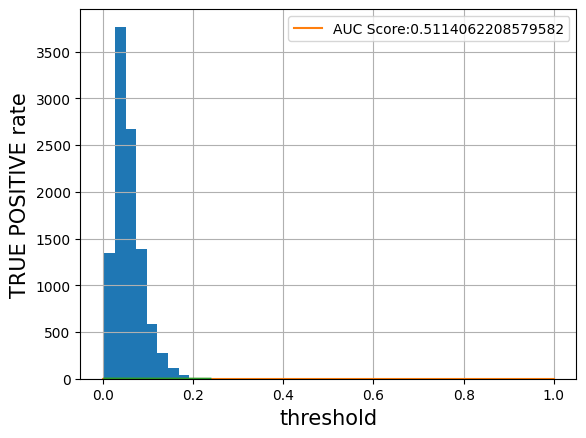

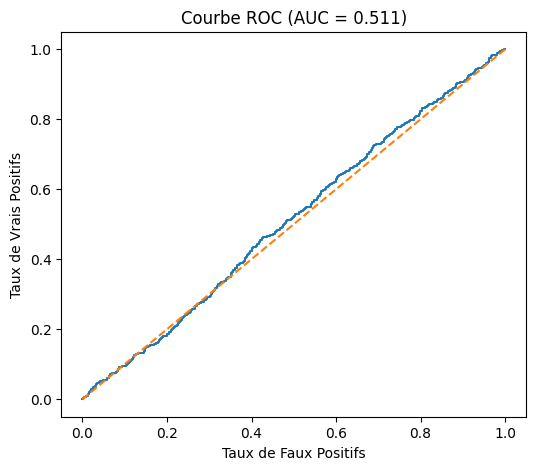

In [24]:
# Entraînement du classificateur
lr = LogisticRegression()
lr.fit(X_test,y_test)

#construction de y_pred
y_pred=lr.predict(X_test)

#Regardons la distribution de probabilité qu'une transaction soit frauduleuse 
y_pred_proba = lr.predict_proba(X_test)

# Métriques au seuil de 50%
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
fpr, tpr, ths = roc_curve(y_test, y_pred_proba[:,1])
roc_auc = auc(fpr, tpr)
accuracy=accuracy_score(y_test,y_pred)

#Matrice de confusion au seuil de 50%
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred,labels = [1,0])


#On peut tracer un histogramme de ces probas
pd.Series(y_pred_proba[:,1]).hist()


"""
fpr : FP rate
tpr : TP rate
ths : threshold

"""

#La fonction roc_curve permet de tracer la courbe ROC 
# à partir d'un vecteur de probabilités de la classe positive (ici (fraudulent=1))
fpr, tpr, ths = roc_curve(y_test, y_pred_proba[:,1])
auc_score = auc(fpr,tpr)
plt.plot(fpr,tpr,label="AUC Score:" + str(auc_score))
plt.xlabel('FALSE POSITIVE rate',fontsize='15')
plt.ylabel('TRUE POSITIVE rate',fontsize='15')
plt.legend(loc='best')

#Recherche d'un seuil (threshold) idéal 
"""
On souhaiterait maximiser le taux de détection d'une transaction frauduleuse
tout en minimisant le taux de transaction non frauduleuses classées comme tel

On va pour cela agir sur le seuil de classification (threshold)

Dans un premier temps, on cherche un seuil qui maximise le recall (sensitivity 
i.e le TP rate) tout en minimisant le FP rate. Néanmoins, le seuil obtenu n'est pas 
le plus optimal selon les situations. 

On va donc dans un second temps utiliser l'indice de Youden qui va nous donner un 
autre seuil de façon optimale selon l'indice de Youden. 
"""

#Recherche seuil sans indice de Youden

index_max= np.where(tpr==np.max(tpr))[0] #indices pour lesquelle tpr est max
threshold_index=np.max(index_max)
threshold= ths[threshold_index]

#On peut le voir graphiquement
plt.plot(ths,tpr)
plt.xlabel('threshold')
plt.ylabel('TRUE POSITIVE rate')

#On obtient donc de nouvelles valeurs prédites ajustées
from sklearn.preprocessing import binarize
y_pred_th= binarize(y_pred_proba, threshold=threshold)
confusion_mat=confusion_matrix(y_test, y_pred_th[:,1],labels=[1,0])
    
#Les métriques associées
recall=tpr[threshold_index]
precision=(confusion_mat[0,0])/(confusion_mat[0,0] + confusion_mat[1,0])
specificity=1-fpr[threshold_index]
f1_score=2*precision*recall/(precision+recall)

#Recherche d'un seuil avec l'indice de Youden
"""
On va cette fois-ci maximiser la quantité : recall + specificty - 1 
On en tirera un seuil optimal noté threshold_y
On s'intéressera aux métrques associées à ce seuil afin de les comparer à
celles sans l'indice de Youden

"""
youden= tpr - fpr
index_max_y= np.where(youden==np.max(youden))
threshold_y_index= np.max(index_max_y)
threshold_y=ths[threshold_y_index]


#On obtient de même de nouvelles valeurs prédites ajustées
y_pred_th_y= binarize(y_pred_proba, threshold=threshold_y)
confusion_mat_y = confusion_matrix(y_test, y_pred_th_y[:,1],labels=[1,0])

#Les métriques associées avec Youden
recall_y=tpr[threshold_y_index]
precision_y=(confusion_mat_y[0,0])/(confusion_mat_y[0,0] + confusion_mat_y[1,0])
specificity_y=1-fpr[threshold_y_index]
f1_score_y=2*precision_y*recall_y/(precision_y+recall_y)

#Affichage des métriques utiles
print("accuracy:" +str(accuracy))
print("AUC: "+ str(auc_score))
print("threshold: " + str(threshold) )
print("recall (sensitivity) : " + str(recall) )
print("precision :" + str(precision))
print("specificity : " + str(specificity) )
print("f1-score avec Youden: " + str(f1_score))
print("threshold avec Youden: " + str(threshold_y) )
print("recall (sensitivity) avec Youden : " + str(recall_y) )
print("precision avec Youden:" + str(precision_y))
print("specificity avec Youden: " + str(specificity_y) )
print("f1-score avec Youden : " + str(f1_score_y))
print("Indice de Youden: " + str(youden[threshold_y_index]))

# Tracé de la courbe ROC
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs')
plt.title('Courbe ROC (AUC = %.3f)' % roc_auc)
plt.show()




SVM

LightGBM

In [ ]:
#

II - Avec SMOTE

Preprocessing : 
• Application SMOTE au dataset X,y 
• Séparation du dataset en train et test

Implémentation SMOTE

In [42]:
#Algorithme SMOTE simplifié (sans SMOTE manuel se reporter à autre fichier si problème)


!pip install imblearn


def smote(A,b,p):
    """
    (A,b) : dataset auquel est appliqué l'algorithme avec A les observations 
    des variables explicatives et b celles de la variable expliquée. 

    p : proportion de la classe minoritaire

    Remarques : On suppose ici que le dataset est traité, i.e que les valeurs manquantes
    ont été remplacées

    sortie :
    X_res, y_res
    
    """
    
    P=A.reset_index(drop=True)
    q=b.reset_index(drop=True)
    
    #On exécute l'algorithme à partir du package imblearn
    from imblearn.over_sampling import SMOTE
    #On créer le modèle smote
    sm = SMOTE(sampling_strategy=p/(1-p), random_state=42) 
    #On applique smote au dataset (X,y) avec la méthode fit_resample
    X_res, y_res = sm.fit_resample(P, q) 
    #On vérifie que les classes ont bien été rééquilibrées
    print('Après SMOTE, comptes :', np.bincount(y_res.astype(int)))



In [44]:
np.bincount(y.astype(int))

array([48490,  2510])

Application SMOTE à X,y

In [45]:
#Proportion 80-20
smote(X,y,0.2)

Après SMOTE, comptes : [48490 12122]


In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
random_state=42, stratify=y)

RandomForest

Régression Logistique

accuracy:0.9507843137254902
AUC: 0.5114062208579582
threshold: 0.0030876476994473848
recall (sensitivity) : 1.0
precision :0.049220511814883815
specificity : 0.0
f1-score avec Youden: 0.0938230071955892
threshold avec Youden: 0.05511582997559403
recall (sensitivity) avec Youden : 0.46215139442231074
precision avec Youden:0.05293308890925756
specificity avec Youden: 0.5738296555990926
f1-score avec Youden : 0.09498675126948539
Indice de Youden: 0.03598105002140334


/opt/python/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/python/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


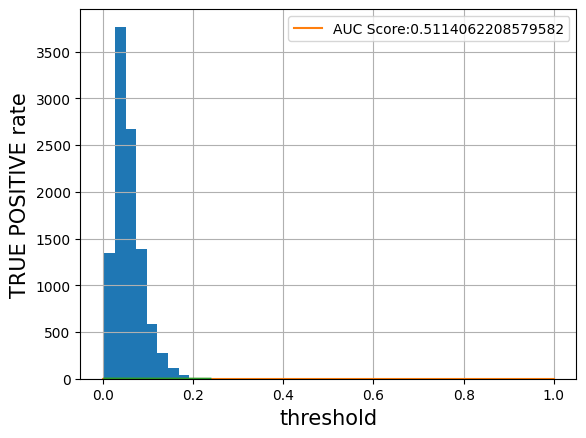

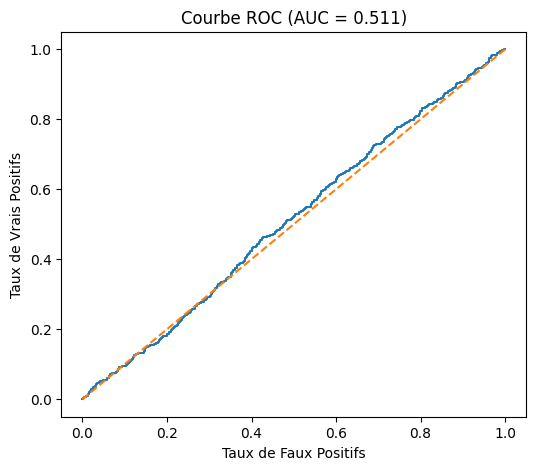

In [47]:
# Entraînement du classificateur
lr = LogisticRegression()
lr.fit(X_test,y_test)

#construction de y_pred
y_pred=lr.predict(X_test)

#Regardons la distribution de probabilité qu'une transaction soit frauduleuse 
y_pred_proba = lr.predict_proba(X_test)

# Métriques au seuil de 50%
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
fpr, tpr, ths = roc_curve(y_test, y_pred_proba[:,1])
roc_auc = auc(fpr, tpr)
accuracy=accuracy_score(y_test,y_pred)

#Matrice de confusion au seuil de 50%
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred,labels = [1,0])


#On peut tracer un histogramme de ces probas
pd.Series(y_pred_proba[:,1]).hist()


"""
fpr : FP rate
tpr : TP rate
ths : threshold

"""

#La fonction roc_curve permet de tracer la courbe ROC 
# à partir d'un vecteur de probabilités de la classe positive (ici (fraudulent=1))
fpr, tpr, ths = roc_curve(y_test, y_pred_proba[:,1])
auc_score = auc(fpr,tpr)
plt.plot(fpr,tpr,label="AUC Score:" + str(auc_score))
plt.xlabel('FALSE POSITIVE rate',fontsize='15')
plt.ylabel('TRUE POSITIVE rate',fontsize='15')
plt.legend(loc='best')

#Recherche d'un seuil (threshold) idéal 
"""
On souhaiterait maximiser le taux de détection d'une transaction frauduleuse
tout en minimisant le taux de transaction non frauduleuses classées comme tel

On va pour cela agir sur le seuil de classification (threshold)

Dans un premier temps, on cherche un seuil qui maximise le recall (sensitivity 
i.e le TP rate) tout en minimisant le FP rate. Néanmoins, le seuil obtenu n'est pas 
le plus optimal selon les situations. 

On va donc dans un second temps utiliser l'indice de Youden qui va nous donner un 
autre seuil de façon optimale selon l'indice de Youden. 
"""

#Recherche seuil sans indice de Youden

index_max= np.where(tpr==np.max(tpr))[0] #indices pour lesquelle tpr est max
threshold_index=np.max(index_max)
threshold= ths[threshold_index]

#On peut le voir graphiquement
plt.plot(ths,tpr)
plt.xlabel('threshold')
plt.ylabel('TRUE POSITIVE rate')

#On obtient donc de nouvelles valeurs prédites ajustées
from sklearn.preprocessing import binarize
y_pred_th= binarize(y_pred_proba, threshold=threshold)
confusion_mat=confusion_matrix(y_test, y_pred_th[:,1],labels=[1,0])
    
#Les métriques associées
recall=tpr[threshold_index]
precision=(confusion_mat[0,0])/(confusion_mat[0,0] + confusion_mat[1,0])
specificity=1-fpr[threshold_index]
f1_score=2*precision*recall/(precision+recall)

#Recherche d'un seuil avec l'indice de Youden
"""
On va cette fois-ci maximiser la quantité : recall + specificty - 1 
On en tirera un seuil optimal noté threshold_y
On s'intéressera aux métrques associées à ce seuil afin de les comparer à
celles sans l'indice de Youden

"""
youden= tpr - fpr
index_max_y= np.where(youden==np.max(youden))
threshold_y_index= np.max(index_max_y)
threshold_y=ths[threshold_y_index]


#On obtient de même de nouvelles valeurs prédites ajustées
y_pred_th_y= binarize(y_pred_proba, threshold=threshold_y)
confusion_mat_y = confusion_matrix(y_test, y_pred_th_y[:,1],labels=[1,0])

#Les métriques associées avec Youden
recall_y=tpr[threshold_y_index]
precision_y=(confusion_mat_y[0,0])/(confusion_mat_y[0,0] + confusion_mat_y[1,0])
specificity_y=1-fpr[threshold_y_index]
f1_score_y=2*precision_y*recall_y/(precision_y+recall_y)

#Affichage des métriques utiles
print("accuracy:" +str(accuracy))
print("AUC: "+ str(auc_score))
print("threshold: " + str(threshold) )
print("recall (sensitivity) : " + str(recall) )
print("precision :" + str(precision))
print("specificity : " + str(specificity) )
print("f1-score avec Youden: " + str(f1_score))
print("threshold avec Youden: " + str(threshold_y) )
print("recall (sensitivity) avec Youden : " + str(recall_y) )
print("precision avec Youden:" + str(precision_y))
print("specificity avec Youden: " + str(specificity_y) )
print("f1-score avec Youden : " + str(f1_score_y))
print("Indice de Youden: " + str(youden[threshold_y_index]))

# Tracé de la courbe ROC
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs')
plt.title('Courbe ROC (AUC = %.3f)' % roc_auc)
plt.show()




SVM

LightGBM